Todo:
- sensitives Klassengewicht Quellen
- EBM Quellen

# Explainable Boosting Machines (EBM)

## Warum EBM?

* **Inhärente Interpretierbarkeit (Glass-Box):** Im Gegensatz zu herkömmlichen Black-Box-Modellen (wie XGBoost oder tiefen neuronalen Netzen), die post-hoc-Erklärungen (wie SHAP) benötigen, ist die EBM von Natur aus vollkommen transparent. Sie basiert auf verallgemeinerten additiven Modellen mit Interaktionen ($GA^2M$):
  $$g(E[y]) = \beta_0 + \sum f_i(x_i) + \sum f_{ij}(x_i, x_j)$$
  Jedes Feature und jede Interaktion wird über eine exakte mathematische Kurve (Spline) gelernt. Wir können später genau ablesen, *warum* das Modell eine Vorhersage trifft.
* **Erkennung nicht-linearer Sport-Muster:** Physische Variablen im Radsport verhalten sich selten linear. Ein optimaler Fahrer-BMI ist beispielsweise stark abhängig vom Profil der Etappe (Flachetappe vs. Hochgebirge). EBMs nutzen hochentwickeltes Tree-Boosting, um solche komplexen, stufenförmigen und nicht-linearen Beziehungen exakt abzubilden, ohne die Interpretierbarkeit zu verlieren.
* **Wissenschaftliche Baseline:** Indem wir ein hochpräzises, aber transparentes Modell als Fundament setzen, generieren wir eine unbestechliche Baseline. Wir können in den späteren Kapiteln genau prüfen, ob hochkomplexe Black-Box-Modelle (XGBoost) oder Foundation-Modelle (TabPFN) überhaupt einen signifikanten Performance-Gewinn gegenüber der gläsernen EBM bieten, der den Verlust der direkten Interpretierbarkeit rechtfertigt.

---

## Zielsetzung dieses Notebooks

In diesem Teilabschnitt setzen wir die theoretischen Anforderungen wie folgt in die Praxis um:
1. **Das Problem übersetzen:** Wir transformieren das komplexe Ranking-Problem in eine binäre Klassifikationsaufgabe („Landet Fahrer X in den Top-n?“).
2. **Chronological Split validieren:** Wir trainieren auf Daten bis einschließlich 2023 und evaluieren die Generalisierungsfähigkeit auf der ungesehenen Zukunftssaison 2024, um jegliches *Temporal Data Leakage* auszuschließen.
3. **Von der Baseline zum Hyperparameter-Tuning:** Wir starten mit einem intuitiven 1D-Modell, führen anschließend einen systematischen Grid-Search mit den neuen historischen Vorjahres-Features (`lag_...`) durch und finalisieren das beste Setup über statistisches Ensembling (`outer_bags`), um die Modellvarianz zu minimieren.

In [7]:
import os
import pandas as pd
import numpy as np
import itertools
import time
import pickle
import matplotlib.pyplot as plt
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score
import seaborn as sns


# Importieren der Daten


In [5]:
pfad = '../../data/processed'

# Pkl Dateien einlesen

X_train = pd.read_pickle(os.path.join(pfad, 'X_train.pkl'))
X_test = pd.read_pickle(os.path.join(pfad, 'X_test.pkl'))
y_class_train = pd.read_pickle(os.path.join(pfad, 'y_class_train.pkl'))
y_class_test = pd.read_pickle(os.path.join(pfad, 'y_class_test.pkl'))
meta_test = pd.read_pickle(os.path.join(pfad, 'meta_test.pkl'))

total_rows = X_train.shape[0] + X_test.shape[0]
pct_train = (X_train.shape[0] / total_rows) * 100
pct_test = (X_test.shape[0] / total_rows) * 100

print("==================================================================")
print(f"Anzahl der Features im Modell: {X_train.shape[1]} Spalten")
print(f"Feature-Liste: {list(X_train.columns)}")
print(f"Trainings-Set (<= 2023)       : {X_train.shape[0]:,} Zeilen ({pct_train:.1f}%)")
print(f"Test-Set      (>= 2024)       : {X_test.shape[0]:,} Zeilen ({pct_test:.1f}%)")


Anzahl der Features im Modell: 17 Spalten
Feature-Liste: ['distance', 'vertical_meters', 'stage_nr', 'team_tier', 'age_at_race', 'rider_bmi', 'wind_stability_index', 'weather_temp_mean', 'weather_temp_trend', 'weather_rain_prob_mean', 'weather_precipitation_mean', 'weather_humidity_mean', 'gradient_final_km', 'lag_rider_points_season', 'lag_rider_rank_season', 'lag_race_competitiveness_median', 'lag_team_power_index']
Trainings-Set (<= 2023)       : 178,246 Zeilen (90.9%)
Test-Set      (>= 2024)       : 17,802 Zeilen (9.1%)


# Basismodell laden

- zu Beginn "intuitives 1D-Basismodell" für das Target target_top_10.
- keine Interaktionen (interactions=0)

Das Modell lernt die 17 Features (inklusive der neuen Vorjahres-Lags) rein isoliert.

Da wir ein starkes Klassenungleichgewicht haben (nur ca. 6–7 % der Zeilen sind eine "1" für Top 10), berechnen wir die sample_weight mit Scikit-Learn, um dem Modell beizubringen, die Top-10-Fahrer nicht einfach zu ignorieren.

## Klassenungleichgewicht (Cost-Sensitive Learning)


Um zu verhindern, dass das Modell die seltene Minderheitsklasse (Top 10) zugunsten der Majoritätsklasse ignoriert, wird die Standard-Verlustfunktion (**Log-Loss**) kostensensitiv modifiziert. Jede Zeile $i$ fließt multipliziert mit einem klassenspezifischen Gewicht $w_i$ in die gewichtete Gesamt-Verlustfunktion ein:

$$L_{\text{gesamt, gewichtet}} = \frac{\sum w_i \cdot L_i}{\sum w_i} \quad \text{mit} \quad w_k = \frac{N}{K \cdot N_k}$$

* **Klassenungleichgewicht kompensieren:** Durch Einsetzen der inversen Häufigkeit ($N$: Zeilen gesamt, $K$: Klassenanzahl, $N_k$: Zeilen der Klasse $k$) erhält jede Top-10-Zeile ein drastisch höheres Gewicht ($w_1 \approx 7.14$) als das Hauptfeld ($w_0 \approx 0.53$).
* **Perfekte Waffengleichheit:** Multipliziert man die absolute Zeilenanzahl mit dem jeweiligen Faktor ($N_1 \cdot w_1 = N_0 \cdot w_0 = \frac{N}{2}$), besitzen beide Klassen trotz extrem ungleicher Startbedingungen exakt denselben maximalen Einfluss von **50% zu 50%** auf die mathematische Optimierung des Algorithmus.

C:\Users\lukas\AppData\Local\Temp\ipykernel_32332\745091881.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_vis, x='Klasse', ax=axes[0], palette=['#34495e', '#e74c3c'], order=['Top 10 (1)', 'Hauptfeld (0)'])
C:\Users\lukas\AppData\Local\Temp\ipykernel_32332\745091881.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_vis, x='Klasse', y='Mathematisches Gewicht', ax=axes[1], palette=['#34495e', '#e74c3c'], errorbar=None, order=['Top 10 (1)', 'Hauptfeld (0)'])
C:\Users\lukas\AppData\Local\Temp\ipykernel_32332\745091881.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and se

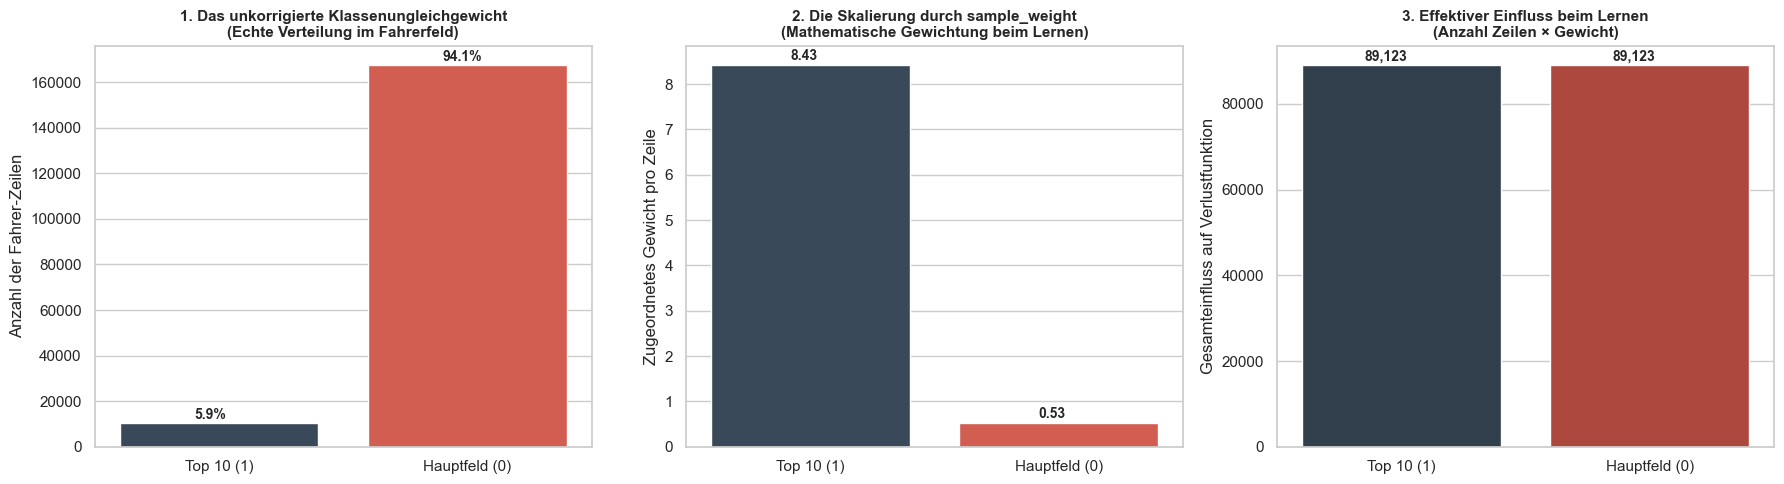

In [11]:
chart_path = '../../data/charts'

# 1. Daten für die Grafiken vorbereiten
y_train_top10 = y_class_train['target_top_10']

# Berechnen der Gewichte
sample_weights_base = compute_sample_weight(class_weight='balanced', y=y_train_top10)

# Erstellen einer temporären Tabelle für eine saubere Visualisierung
df_vis = pd.DataFrame({
    'Klasse': y_train_top10.map({0: 'Hauptfeld (0)', 1: 'Top 10 (1)'}),
    'Mathematisches Gewicht': sample_weights_base
})

# Berechnung effektive Werte (Grafik 3)
df_effektiv = df_vis.groupby('Klasse', as_index=False).sum()
df_effektiv.rename(columns={'Mathematisches Gewicht': 'Effektives Gesamtgewicht'}, inplace=True)

# 2. Plot-Bereich definieren (1 Reihe, 3 Spalten für ein sauberes horizontales Layout)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# --- 1: Das unkorrigierte Klassenungleichgewicht ---
sns.countplot(data=df_vis, x='Klasse', ax=axes[0], palette=['#34495e', '#e74c3c'], order=['Top 10 (1)', 'Hauptfeld (0)'])
axes[0].set_title('1. Das unkorrigierte Klassenungleichgewicht\n(Echte Verteilung im Fahrerfeld)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Anzahl der Fahrer-Zeilen')
axes[0].set_xlabel('')

# Prozentuale Labels auf die Balken setzen
total = len(df_vis)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + (total * 0.01)
    axes[0].annotate(percentage, (x, y), fontweight='bold', fontsize=10)

# --- 2: Die Skalierung durch sample_weight ---
sns.barplot(data=df_vis, x='Klasse', y='Mathematisches Gewicht', ax=axes[1], palette=['#34495e', '#e74c3c'], errorbar=None, order=['Top 10 (1)', 'Hauptfeld (0)'])
axes[1].set_title('2. Die Skalierung durch sample_weight\n(Mathematische Gewichtung beim Lernen)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Zugeordnetes Gewicht pro Zeile')
axes[1].set_xlabel('')

# Exakte Gewichtswerte auf die Balken schreiben
for p in axes[1].patches:
    weight_val = f'{p.get_height():.2f}'
    x = p.get_x() + p.get_width() / 2 - 0.08
    y = p.get_height() + 0.1
    axes[1].annotate(weight_val, (x, y), fontweight='bold', fontsize=10)

# --- 3: Das resultierende mathematische Gleichgewicht ---
sns.barplot(data=df_effektiv, x='Klasse', y='Effektives Gesamtgewicht', ax=axes[2], palette=['#2c3e50', '#c0392b'], order=['Top 10 (1)', 'Hauptfeld (0)'])
axes[2].set_title('3. Effektiver Einfluss beim Lernen\n(Anzahl Zeilen × Gewicht)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Gesamteinfluss auf Verlustfunktion')
axes[2].set_xlabel('')

# Werte auf Grafik 3 schreiben (wird exakt gleich hoch sein!)
for p in axes[2].patches:
    total_weight_val = f'{p.get_height():,.0f}'
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + (df_effektiv['Effektives Gesamtgewicht'].max() * 0.01)
    axes[2].annotate(total_weight_val, (x, y), fontweight='bold', fontsize=10)

# Layout optimieren, speichern und anzeigen
plt.tight_layout()
plt.savefig(os.path.join(chart_path, '10-01-02_01-klassenungleichgewicht_vs_gewichte.png'), dpi=300)
plt.show()